In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("Student_performance_data _.csv")

In [35]:
# check missing values
df.isnull().sum()


StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [36]:
# check missing values
print("Missing values per column:")
print(df.isnull().sum())

# percentage missing
print("\nMissing percentage:")
print((df.isnull().sum()/len(df))*100)

# handling missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':  
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values per column:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Missing percentage:
StudentID            0.0
Age                  0.0
Gender               0.0
Ethnicity            0.0
ParentalEducation    0.0
StudyTimeWeekly      0.0
Absences             0.0
Tutoring             0.0
ParentalSupport      0.0
Extracurricular      0.0
Sports               0.0
Music                0.0
Volunteering         0.0
GPA                  0.0
GradeClass           0.0
dtype: float64

Missing values after handling:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring   

In [37]:
# 2. Check and handle duplicate data
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())

# Unique value checking and replacing (example for categorical columns)
for col in df.select_dtypes(include='object').columns:
    print(f"{col} unique values:", df[col].unique())
    # Example: replace inconsistent values if needed
    # df[col] = df[col].replace({'M':'Male', 'F':'Female'})

Duplicate rows before: 0
Duplicate rows after: 0


In [38]:
# Encode categorical features using pandas get_dummies
cat_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Categorical columns one-hot encoded:", list(cat_cols))

Categorical columns one-hot encoded: []


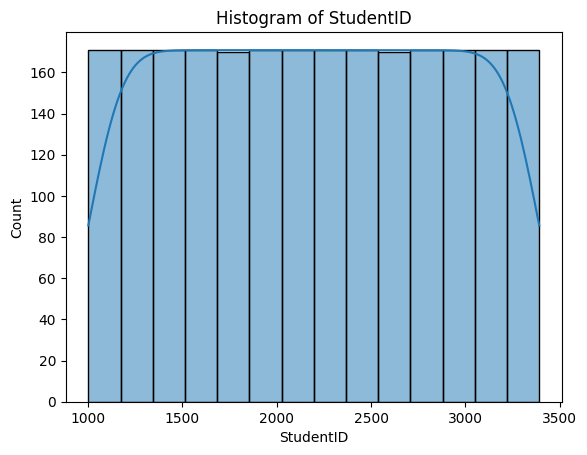

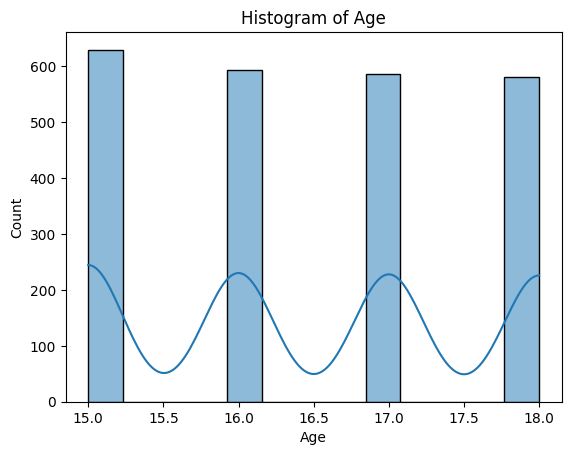

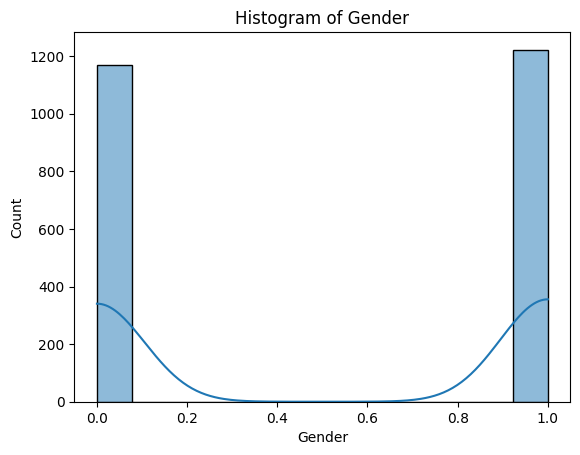

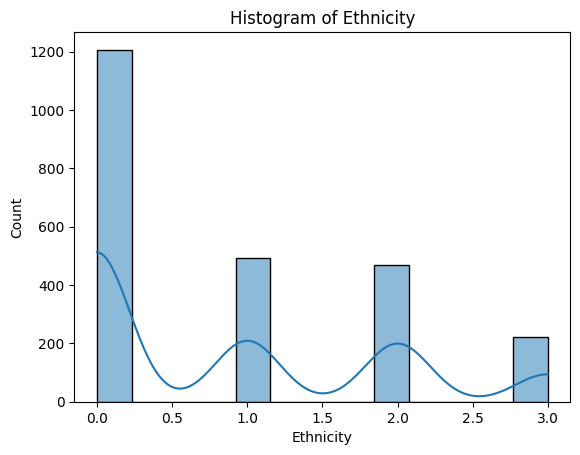

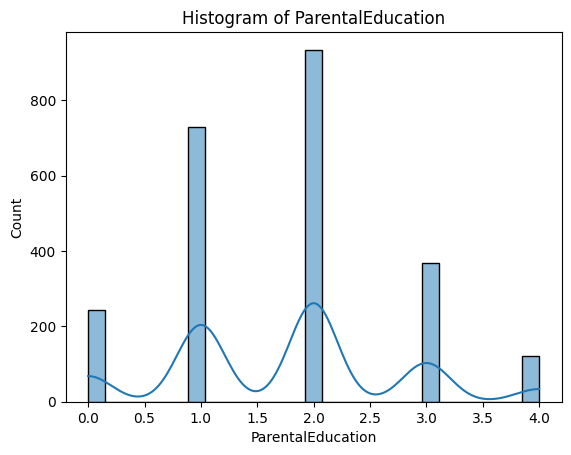

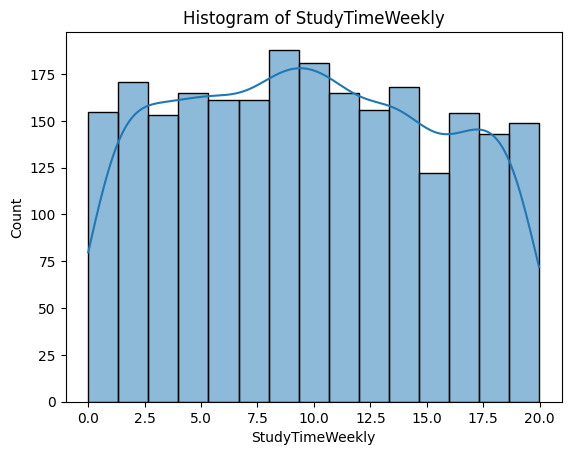

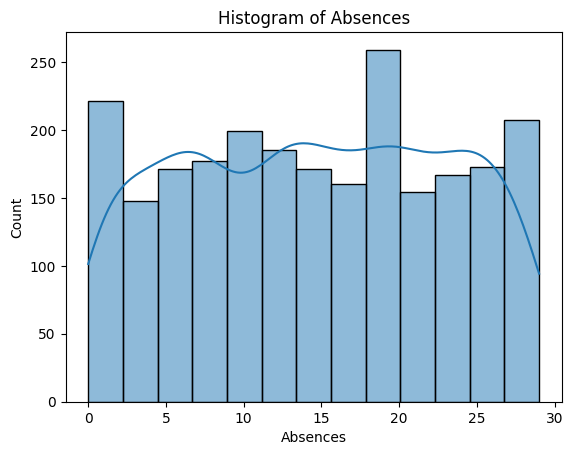

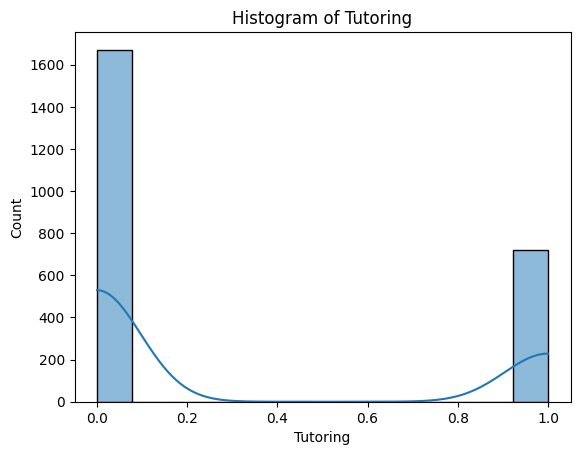

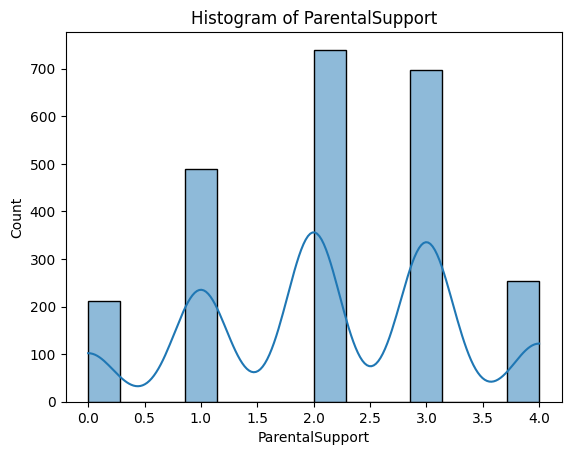

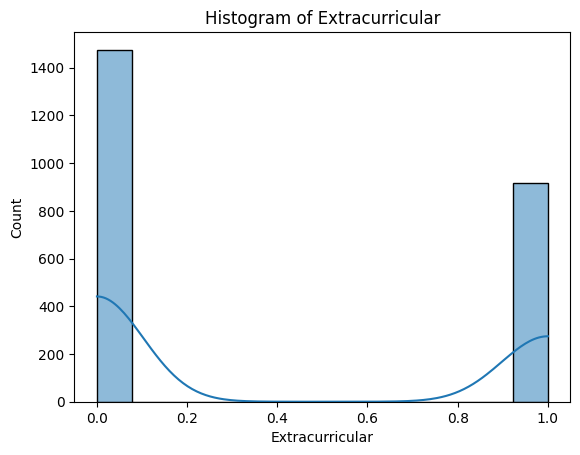

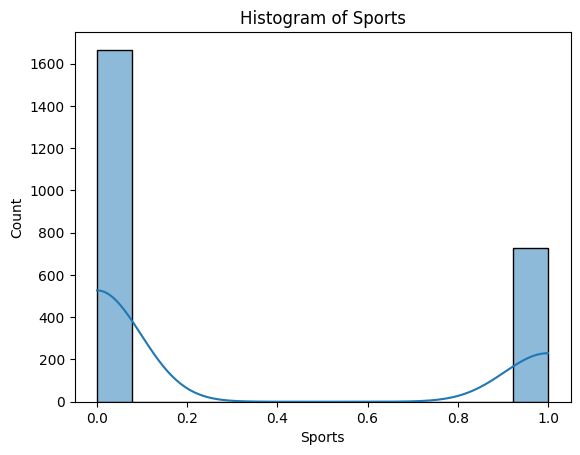

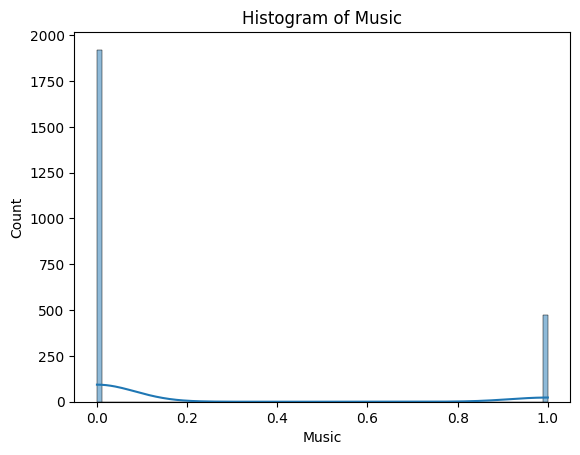

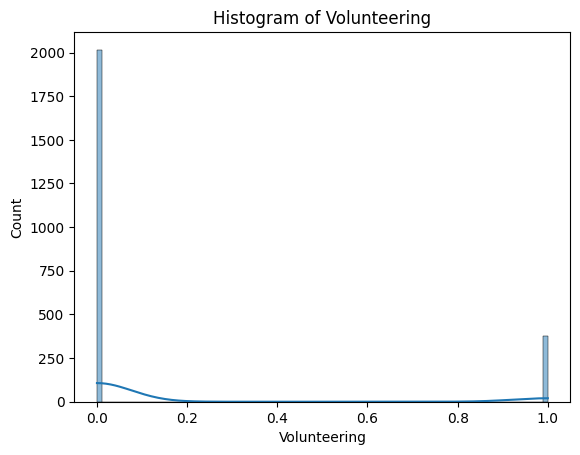

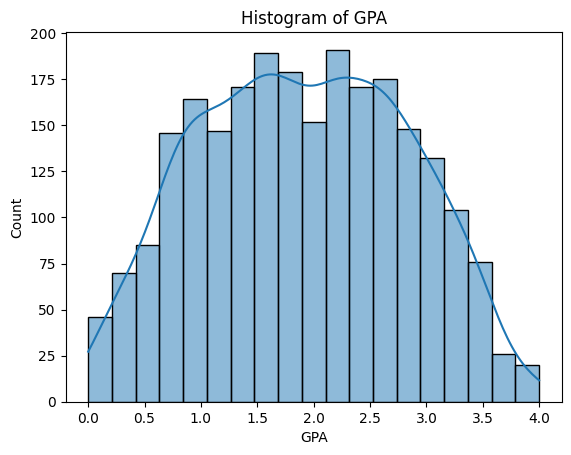

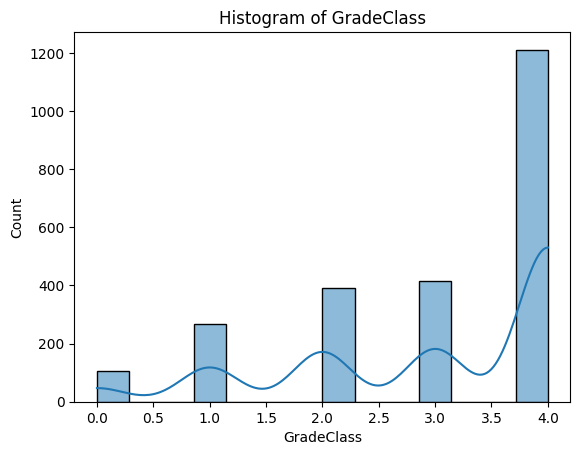

Describe (before outlier handling):
         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417 

In [39]:
# Basic EDA: Graphs and describe
# Numeric features
cat_cols = df.select_dtypes(include='object').columns
#categorical features
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()
#numeric feature
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()


# Static analysis
print("Describe (before outlier handling):")
print(df.describe())

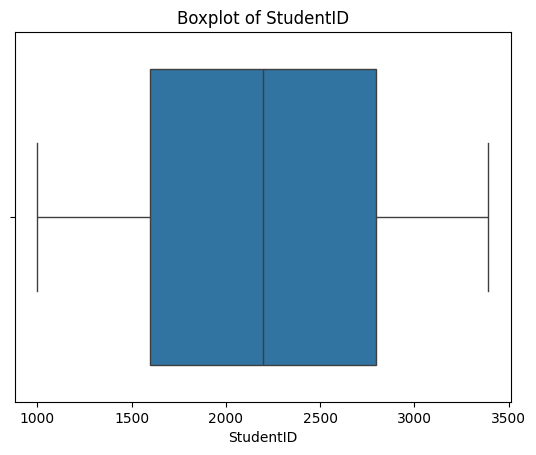

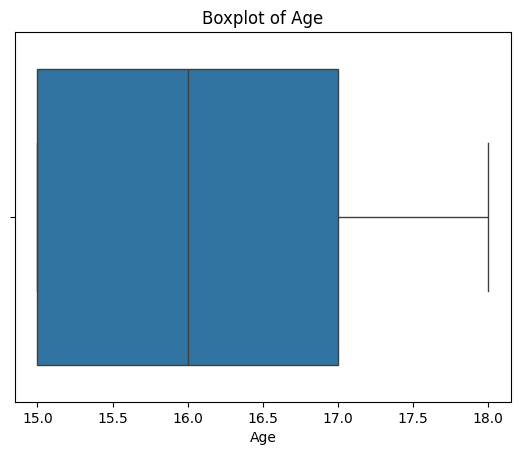

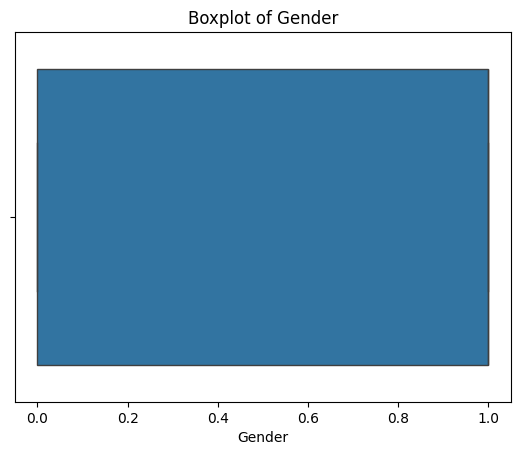

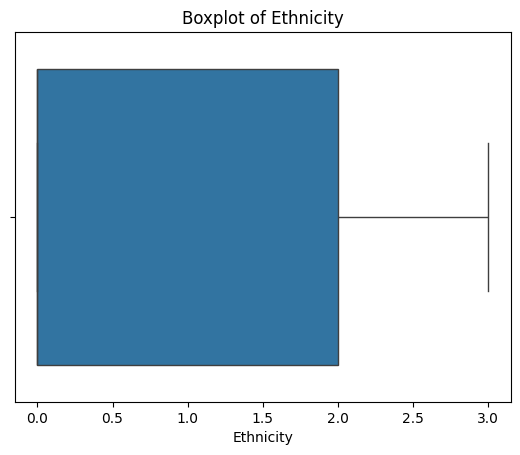

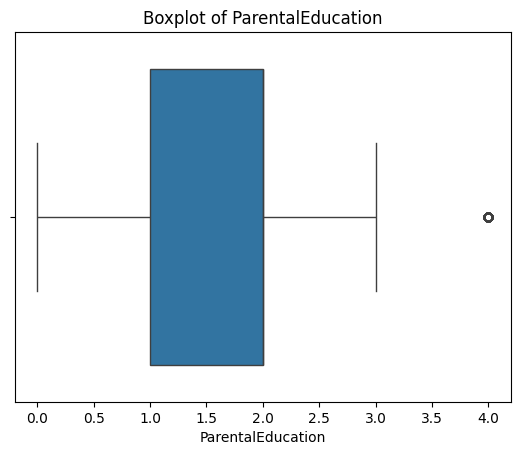

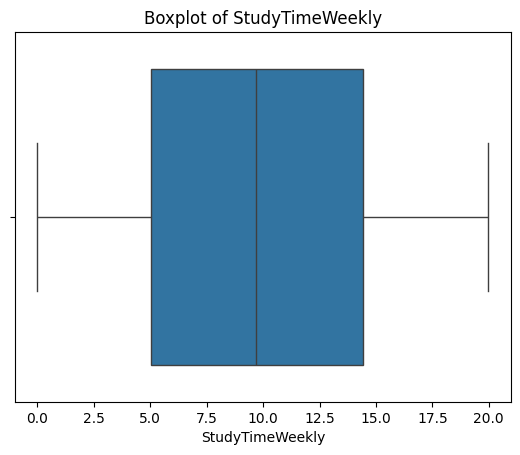

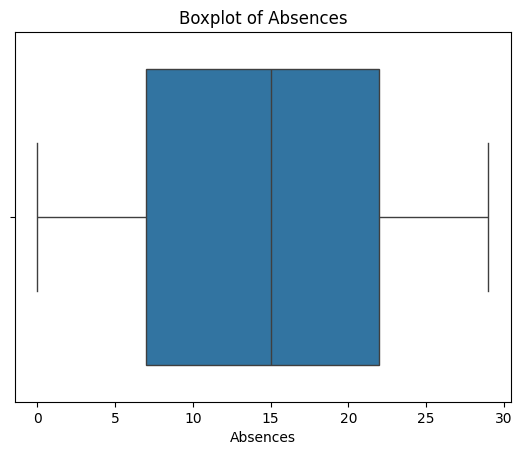

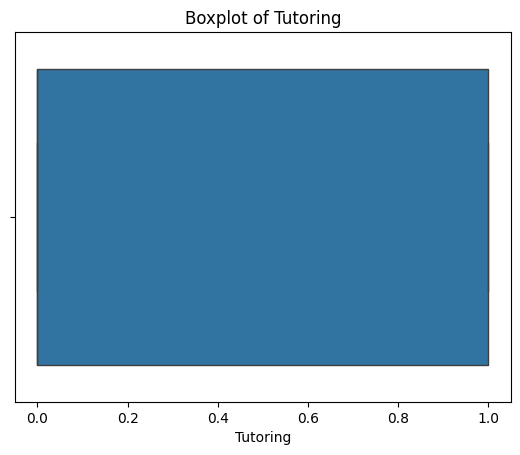

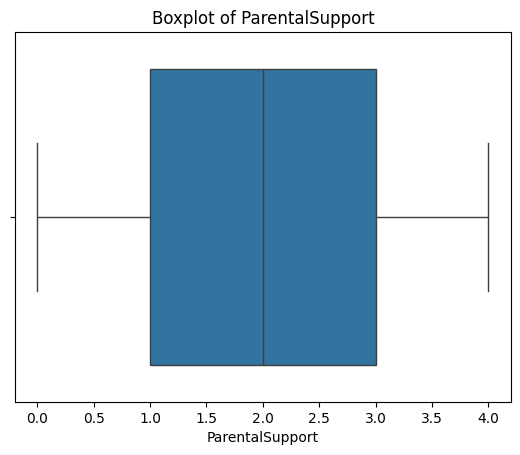

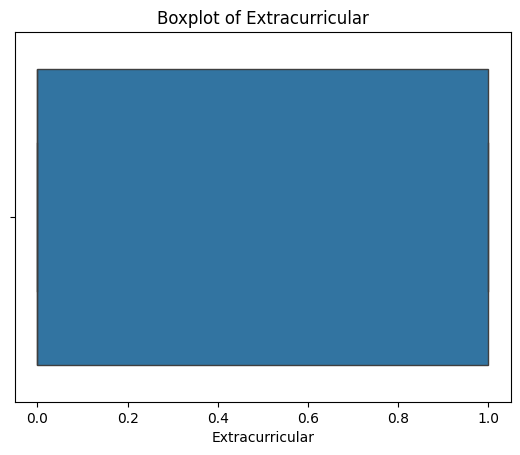

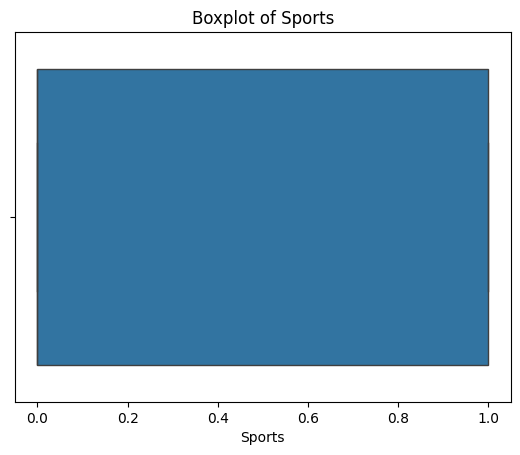

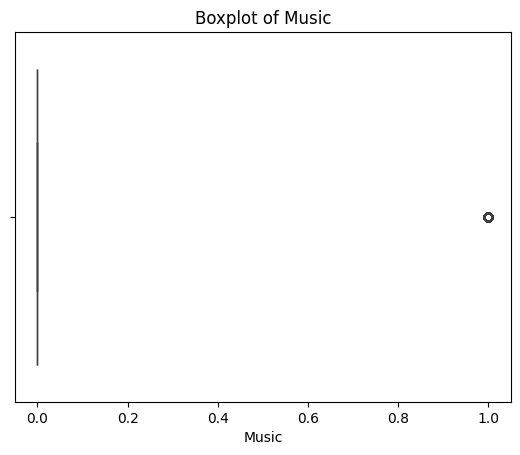

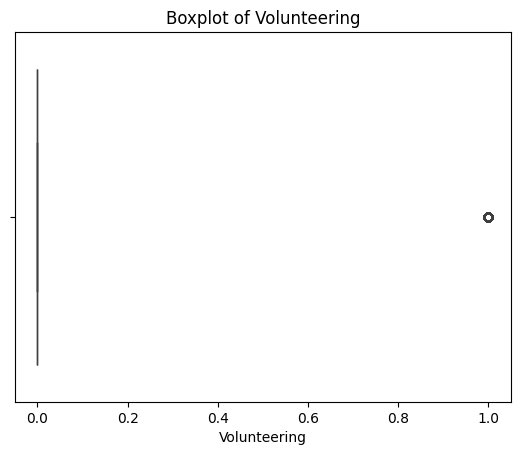

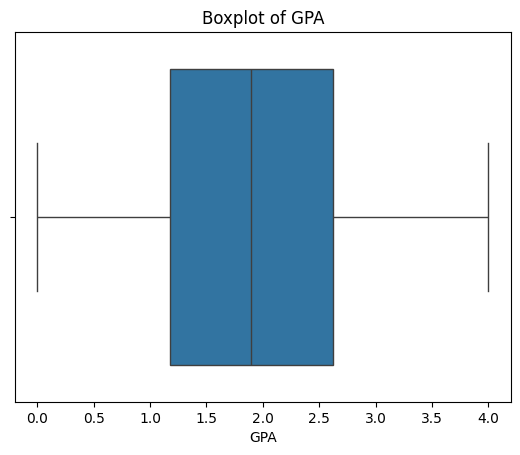

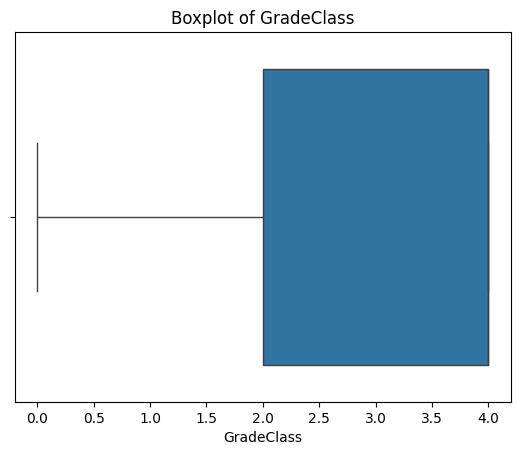

In [40]:
#outlier handling
#boxplot visualization
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [41]:
#IQR Method
df_iqr = df.copy()

for col in num_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_iqr = df_iqr[(df_iqr[col] >= lower) & (df_iqr[col] <= upper)]

print("Shape after IQR:", df_iqr.shape)


Shape after IQR: (1552, 15)


In [42]:
# Z-Method
#  Copy dataframe
df_z = df.copy()

# Select numeric columns
num_cols = df.select_dtypes(include=np.number).columns

# Calculate Z-score manually
z_scores = (df_z[num_cols] - df_z[num_cols].mean()) / df_z[num_cols].std()

# Keep only rows where all numeric features have |Z| < 3
df_z = df_z[(z_scores.abs() < 3).all(axis=1)]

print("Shape after Z-score outlier removal:", df_z.shape)


Shape after Z-score outlier removal: (2392, 15)


In [43]:
#selecting iqr method
df_final = df_iqr

print("Final dataset shape:", df_final.shape)

print("\nDescribe AFTER outlier handling:")
print(df_final.describe())


Final dataset shape: (1552, 15)

Describe AFTER outlier handling:
         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  1552.000000  1552.000000  1552.000000  1552.000000        1552.000000   
mean   2199.197809    16.449098     0.503866     0.871134           1.617268   
std     696.839394     1.125858     0.500146     1.023334           0.881304   
min    1002.000000    15.000000     0.000000     0.000000           0.000000   
25%    1594.750000    15.000000     0.000000     0.000000           1.000000   
50%    2201.500000    16.000000     1.000000     0.000000           2.000000   
75%    2810.250000    17.000000     1.000000     2.000000           2.000000   
max    3389.000000    18.000000     1.000000     3.000000           3.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      1552.000000  1552.000000  1552.000000      1552.000000   
mean          9.848517    14.574742     0.317010         2.108247   
std   

In [44]:
#Model training
print(df_final.columns)


Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')
